In [1]:
# Run this once per kernel before all other cells
%pip install -q --upgrade pip
%pip install -q pandas matplotlib pyarrow fastparquet ipython


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# March 6 Snapshot Analysis (Latest Runs)

This notebook focuses on S3 snapshot artifacts for **March 6, 2026** only and performs detailed analysis across all model families found that day.

It selects one run per model family using this rule:
- If `PREFER_COMPLETE_RUNS=True`, pick the latest run with full strategy/horizon coverage (default 6 = 3 strategies x 2 horizons).
- If no complete run exists for a family, fall back to the latest available run that day.


## Dependencies
If needed, install: `pip install pandas pyarrow matplotlib`


In [2]:
from __future__ import annotations

import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

pd.set_option("display.max_columns", None)
plt.style.use("default")


In [3]:
# Parameters
SNAPSHOT_ROOT = Path("../analysis/s3_snapshots/models/snapshots")
TARGET_DATE = "2026-03-06"
EXPECTED_CONFIGS_PER_FAMILY = 6  # 3 strategies x 2 horizons
PREFER_COMPLETE_RUNS = True

if not SNAPSHOT_ROOT.exists():
    raise FileNotFoundError(f"Snapshot root not found: {SNAPSHOT_ROOT.resolve()}")

print(f"snapshot root: {SNAPSHOT_ROOT.resolve()}")
print(f"target date: {TARGET_DATE}")
print(f"prefer complete runs: {PREFER_COMPLETE_RUNS}")


snapshot root: /Users/wkdghdus/Desktop/coding/clipfarm/video-virality-predictor/analysis/s3_snapshots/models/snapshots
target date: 2026-03-06
prefer complete runs: True


In [4]:
RUN_TS_RE = re.compile(r"(20\d{6}T\d{6}Z)$")

def path_token(path: Path, key: str) -> str | None:
    prefix = f"{key}="
    for part in path.parts:
        if part.startswith(prefix):
            return part.split("=", 1)[1]
    return None

def run_timestamp(run_id: str | None) -> pd.Timestamp:
    if not run_id:
        return pd.NaT
    match = RUN_TS_RE.search(run_id)
    if not match:
        return pd.NaT
    return pd.to_datetime(match.group(1), format="%Y%m%dT%H%M%SZ", utc=True)


### Metrics Ingestion and Canonical View

This cell builds the master metrics table by reading every `metrics_summary.json` under the snapshot root and flattening per-model validation/test metrics into rows.

What this represents:
- One row = one `(run_id, model_family, strategy, horizon, model)` configuration.
- `val_*` metrics reflect model selection quality.
- `test_*` metrics reflect generalization quality.

How to interpret:
- Lower `*_mae_log` and `*_rmse_log` are better.
- Higher `*_r2_log` is better.
- `strategy_horizon` is a convenience key used by later comparison plots.



In [5]:
# Load metrics rows from metrics_summary.json
metric_files = sorted(SNAPSHOT_ROOT.rglob("metrics_summary.json"))
rows: list[dict[str, object]] = []

for path in metric_files:
    run_id = path_token(path, "run_id")
    strategy = path_token(path, "strategy")
    horizon = path_token(path, "horizon")
    model_family_path = path_token(path, "model")
    payload = json.loads(path.read_text(encoding="utf-8"))
    model_family = payload.get("model_family") or model_family_path
    models = payload.get("models") or {}

    run_ts = run_timestamp(run_id)
    run_date = run_ts.strftime("%Y-%m-%d") if pd.notna(run_ts) else None
    for model_name, split_payload in models.items():
        val = (split_payload or {}).get("val", {})
        test = (split_payload or {}).get("test", {})
        rows.append(
            {
                "run_id": run_id,
                "run_timestamp": run_ts,
                "run_date": run_date,
                "model_family": model_family,
                "strategy": strategy,
                "horizon": int(horizon) if horizon else np.nan,
                "model": model_name,
                "val_rmse_log": val.get("rmse_log"),
                "val_mae_log": val.get("mae_log"),
                "val_r2_log": val.get("r2_log"),
                "val_rmse_raw": val.get("rmse_raw"),
                "val_mae_raw": val.get("mae_raw"),
                "test_rmse_log": test.get("rmse_log"),
                "test_mae_log": test.get("mae_log"),
                "test_r2_log": test.get("r2_log"),
                "test_rmse_raw": test.get("rmse_raw"),
                "test_mae_raw": test.get("mae_raw"),
                "metrics_path": str(path),
            }
        )

metrics_df = pd.DataFrame(rows)
if metrics_df.empty:
    raise ValueError("No metrics rows found.")

metrics_df["horizon"] = metrics_df["horizon"].astype("Int64")
metrics_df["strategy_horizon"] = metrics_df["strategy"].astype(str) + "|h=" + metrics_df["horizon"].astype(str)

march_df = metrics_df[metrics_df["run_date"] == TARGET_DATE].copy()
if march_df.empty:
    raise ValueError(f"No runs found for date={TARGET_DATE}")

print(f"rows in all metrics: {len(metrics_df)}")
print(f"rows on {TARGET_DATE}: {len(march_df)}")


rows in all metrics: 49
rows on 2026-03-06: 25


### Run Selection Logic (March 6)

This cell summarizes run coverage for March 6 and chooses exactly one run per model family for fair comparison.

What this represents:
- `coverage` shows how many configs each run contains (`n_configs`).
- `selection_df` is the final run set used downstream.

How to interpret:
- With `PREFER_COMPLETE_RUNS=True`, the notebook prefers full 6-config runs over partial runs.
- If a family has no full run, it falls back to the latest available run.
- This avoids skew from incomplete experiments.



In [6]:
# Select one run per model family for target date
coverage = (
    march_df.groupby(["run_id", "model_family"], as_index=False)
    .agg(
        run_timestamp=("run_timestamp", "max"),
        n_configs=("model", "count"),
        strategies=("strategy", lambda s: ",".join(sorted(pd.unique(s)))),
        horizons=("horizon", lambda s: ",".join(str(x) for x in sorted(pd.unique(s)))),
        best_val_mae_log=("val_mae_log", "min"),
    )
)

selected_rows = []
for model_family, g in coverage.groupby("model_family"):
    g = g.sort_values("run_timestamp")
    chosen = None
    if PREFER_COMPLETE_RUNS:
        complete = g[g["n_configs"] >= EXPECTED_CONFIGS_PER_FAMILY]
        if not complete.empty:
            chosen = complete.iloc[-1]
    if chosen is None:
        chosen = g.iloc[-1]
    selected_rows.append(chosen)

selection_df = pd.DataFrame(selected_rows).sort_values("model_family")
selected_run_ids = set(selection_df["run_id"])

print("Run coverage on target date:")
display(coverage.sort_values(["run_timestamp", "model_family"]))
print("Selected runs:")
display(selection_df)


Run coverage on target date:


,run_id,model_family,run_timestamp,n_configs,strategies,horizons,best_val_mae_log
0,colab-concat_mlp-20260306T054620Z,concat_mlp,2026-03-06 05:46:20+00:00,6,"concat,max_pool,sum_pool","7,30",1.180919
1,colab-concat_mlp-20260306T054901Z,concat_mlp,2026-03-06 05:49:01+00:00,1,concat,7,1.232506
2,colab-gated_fusion_mlp-20260306T054937Z,gated_fusion_mlp,2026-03-06 05:49:37+00:00,6,"concat,max_pool,sum_pool","7,30",1.302681
4,colab-ridge-20260306T070324Z,ridge,2026-03-06 07:03:24+00:00,6,"concat,max_pool,sum_pool","7,30",1.313467
3,colab-gbdt-20260306T070623Z,gbdt,2026-03-06 07:06:23+00:00,6,"concat,max_pool,sum_pool","7,30",1.072131


Selected runs:


,run_id,model_family,run_timestamp,n_configs,strategies,horizons,best_val_mae_log
0,colab-concat_mlp-20260306T054620Z,concat_mlp,2026-03-06 05:46:20+00:00,6,"concat,max_pool,sum_pool","7,30",1.180919
2,colab-gated_fusion_mlp-20260306T054937Z,gated_fusion_mlp,2026-03-06 05:49:37+00:00,6,"concat,max_pool,sum_pool","7,30",1.302681
3,colab-gbdt-20260306T070623Z,gbdt,2026-03-06 07:06:23+00:00,6,"concat,max_pool,sum_pool","7,30",1.072131
4,colab-ridge-20260306T070324Z,ridge,2026-03-06 07:03:24+00:00,6,"concat,max_pool,sum_pool","7,30",1.313467


### Selected Metrics Matrix

This cell materializes the final evaluation matrix from selected runs only.

What this represents:
- `selected_metrics` is the core dataset used for all comparisons and plots.
- `generalization_gap_mae_log = test_mae_log - val_mae_log`.

How to interpret:
- Positive gap: test error is worse than validation (possible overfitting).
- Negative gap: test error is lower than validation (can occur from split variance).
- Use this table to sanity-check that each family has expected strategy/horizon coverage.



In [7]:
selected_metrics = march_df[march_df["run_id"].isin(selected_run_ids)].copy()
selected_metrics["generalization_gap_mae_log"] = selected_metrics["test_mae_log"] - selected_metrics["val_mae_log"]
selected_metrics = selected_metrics.sort_values(["model_family", "horizon", "strategy"]).reset_index(drop=True)

print(f"Selected metric rows: {len(selected_metrics)}")
display(selected_metrics.head(20))


Selected metric rows: 24


,run_id,run_timestamp,run_date,model_family,strategy,horizon,model,val_rmse_log,val_mae_log,val_r2_log,val_rmse_raw,val_mae_raw,test_rmse_log,test_mae_log,test_r2_log,test_rmse_raw,test_mae_raw,metrics_path,strategy_horizon,generalization_gap_mae_log
0,colab-concat_mlp-20260306T054620Z,2026-03-06 05:46:20+00:00,2026-03-06,concat_mlp,concat,7,concat_mlp,1.547470,1.232506,0.262455,3.491986e+06,8.958830e+05,1.549624,1.241039,0.247459,2.596384e+06,8.270209e+05,../analysis/s3_snapshots/models/snapshots/run_...,concat|h=7,0.008533
1,colab-concat_mlp-20260306T054620Z,2026-03-06 05:46:20+00:00,2026-03-06,concat_mlp,max_pool,7,concat_mlp,1.507626,1.180919,0.299947,3.504154e+06,8.760769e+05,1.533484,1.224115,0.263053,2.665616e+06,8.262075e+05,../analysis/s3_snapshots/models/snapshots/run_...,max_pool|h=7,0.043196
2,colab-concat_mlp-20260306T054620Z,2026-03-06 05:46:20+00:00,2026-03-06,concat_mlp,sum_pool,7,concat_mlp,1.544830,1.230808,0.264969,3.455328e+06,9.060291e+05,1.592141,1.264093,0.205597,2.568460e+06,8.588471e+05,../analysis/s3_snapshots/models/snapshots/run_...,sum_pool|h=7,0.033285
3,colab-concat_mlp-20260306T054620Z,2026-03-06 05:46:20+00:00,2026-03-06,concat_mlp,concat,30,concat_mlp,2.906071,2.146299,0.209393,7.504113e+06,2.415432e+06,2.601274,1.962592,0.272329,2.696937e+08,1.198634e+07,../analysis/s3_snapshots/models/snapshots/run_...,concat|h=30,-0.183706
4,colab-concat_mlp-20260306T054620Z,2026-03-06 05:46:20+00:00,2026-03-06,concat_mlp,max_pool,30,concat_mlp,2.836271,2.088795,0.246915,7.326218e+06,2.432846e+06,2.507335,1.887748,0.323936,8.977795e+09,3.337099e+08,../analysis/s3_snapshots/models/snapshots/run_...,max_pool|h=30,-0.201047
5,colab-concat_mlp-20260306T054620Z,2026-03-06 05:46:20+00:00,2026-03-06,concat_mlp,sum_pool,30,concat_mlp,2.938902,2.121321,0.191428,7.258720e+06,2.409561e+06,2.595990,1.884004,0.275283,3.947137e+11,1.458111e+10,../analysis/s3_snapshots/models/snapshots/run_...,sum_pool|h=30,-0.237317
6,colab-gated_fusion_mlp-20260306T054937Z,2026-03-06 05:49:37+00:00,2026-03-06,gated_fusion_mlp,concat,7,gated_fusion_mlp,1.631550,1.302681,0.180131,3.610902e+06,9.121937e+05,1.616372,1.302053,0.181233,2.754009e+06,8.677161e+05,../analysis/s3_snapshots/models/snapshots/run_...,concat|h=7,-0.000628
7,colab-gated_fusion_mlp-20260306T054937Z,2026-03-06 05:49:37+00:00,2026-03-06,gated_fusion_mlp,max_pool,7,gated_fusion_mlp,1.631550,1.302681,0.180131,3.610902e+06,9.121937e+05,1.616372,1.302053,0.181233,2.754009e+06,8.677161e+05,../analysis/s3_snapshots/models/snapshots/run_...,max_pool|h=7,-0.000628
8,colab-gated_fusion_mlp-20260306T054937Z,2026-03-06 05:49:37+00:00,2026-03-06,gated_fusion_mlp,sum_pool,7,gated_fusion_mlp,1.631550,1.302681,0.180131,3.610902e+06,9.121937e+05,1.616372,1.302053,0.181233,2.754009e+06,8.677161e+05,../analysis/s3_snapshots/models/snapshots/run_...,sum_pool|h=7,-0.000628
9,colab-gated_fusion_mlp-20260306T054937Z,2026-03-06 05:49:37+00:00,2026-03-06,gated_fusion_mlp,concat,30,gated_fusion_mlp,2.888325,2.214271,0.219018,7.647719e+06,2.449964e+06,2.665033,2.048295,0.236221,3.464861e+07,3.277339e+06,../analysis/s3_snapshots/models/snapshots/run_...,concat|h=30,-0.165976


### Detailed Metric Table

This is the full metric grid for all selected configurations, grouped by model family and horizon.

What this represents:
- Side-by-side val/test MAE, RMSE, and R2 in log space.
- Direct comparability across families, strategies, and horizons.

How to interpret:
- Start from `test_mae_log` and `test_rmse_log` for ranking.
- Use `test_r2_log` as fit-quality context (especially at horizon 30).
- Use `generalization_gap_mae_log` to detect unstable configs.



In [8]:
# Detailed table by model family
table_cols = [
    "model_family",
    "run_id",
    "strategy",
    "horizon",
    "val_mae_log",
    "test_mae_log",
    "val_rmse_log",
    "test_rmse_log",
    "val_r2_log",
    "test_r2_log",
    "generalization_gap_mae_log",
]
display(selected_metrics[table_cols].sort_values(["model_family", "horizon", "strategy"]))


,model_family,run_id,strategy,horizon,val_mae_log,test_mae_log,val_rmse_log,test_rmse_log,val_r2_log,test_r2_log,generalization_gap_mae_log
0,concat_mlp,colab-concat_mlp-20260306T054620Z,concat,7,1.232506,1.241039,1.547470,1.549624,0.262455,0.247459,0.008533
1,concat_mlp,colab-concat_mlp-20260306T054620Z,max_pool,7,1.180919,1.224115,1.507626,1.533484,0.299947,0.263053,0.043196
2,concat_mlp,colab-concat_mlp-20260306T054620Z,sum_pool,7,1.230808,1.264093,1.544830,1.592141,0.264969,0.205597,0.033285
3,concat_mlp,colab-concat_mlp-20260306T054620Z,concat,30,2.146299,1.962592,2.906071,2.601274,0.209393,0.272329,-0.183706
4,concat_mlp,colab-concat_mlp-20260306T054620Z,max_pool,30,2.088795,1.887748,2.836271,2.507335,0.246915,0.323936,-0.201047
5,concat_mlp,colab-concat_mlp-20260306T054620Z,sum_pool,30,2.121321,1.884004,2.938902,2.595990,0.191428,0.275283,-0.237317
6,gated_fusion_mlp,colab-gated_fusion_mlp-20260306T054937Z,concat,7,1.302681,1.302053,1.631550,1.616372,0.180131,0.181233,-0.000628
7,gated_fusion_mlp,colab-gated_fusion_mlp-20260306T054937Z,max_pool,7,1.302681,1.302053,1.631550,1.616372,0.180131,0.181233,-0.000628
8,gated_fusion_mlp,colab-gated_fusion_mlp-20260306T054937Z,sum_pool,7,1.302681,1.302053,1.631550,1.616372,0.180131,0.181233,-0.000628
9,gated_fusion_mlp,colab-gated_fusion_mlp-20260306T054937Z,concat,30,2.214271,2.048295,2.888325,2.665033,0.219018,0.236221,-0.165976


### Heatmap: Test MAE(log)

This plot compresses the comparison into a matrix view.

What this represents:
- Rows: model families.
- Columns: `strategy | horizon`.
- Cells: `test_mae_log` (lower is better).

How to interpret:
- Darker/lower cells indicate stronger generalization.
- Horizontal consistency indicates strategy robustness for a model family.
- Vertical separation indicates relative family performance for each setting.



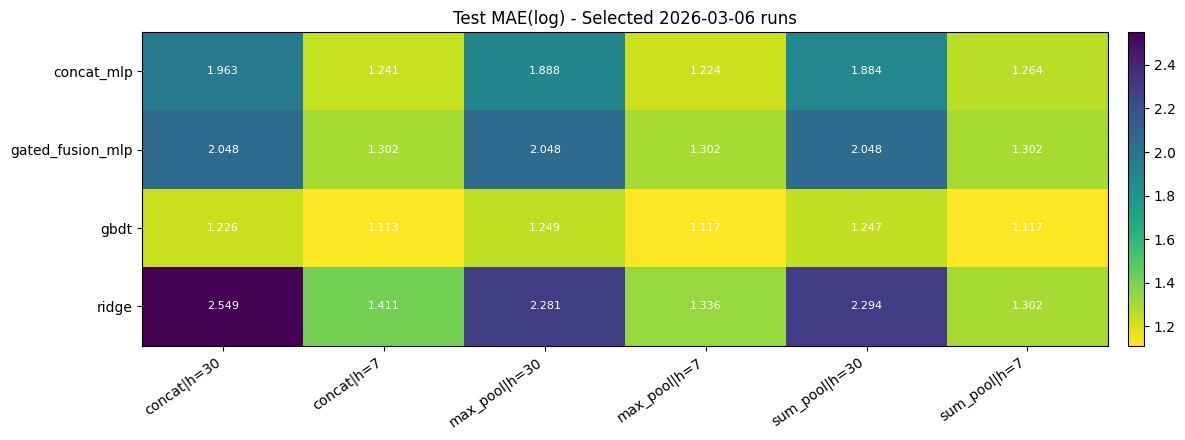

In [9]:
# Heatmap: test MAE(log) by family and strategy/horizon
pivot_test = selected_metrics.pivot_table(
    index="model_family",
    columns="strategy_horizon",
    values="test_mae_log",
    aggfunc="min",
)

fig, ax = plt.subplots(figsize=(12, 4.5))
im = ax.imshow(pivot_test.values, aspect="auto", cmap="viridis_r")
ax.set_xticks(range(len(pivot_test.columns)))
ax.set_xticklabels(list(pivot_test.columns), rotation=35, ha="right")
ax.set_yticks(range(len(pivot_test.index)))
ax.set_yticklabels(list(pivot_test.index))
ax.set_title(f"Test MAE(log) - Selected {TARGET_DATE} runs")
for i in range(pivot_test.shape[0]):
    for j in range(pivot_test.shape[1]):
        v = pivot_test.iloc[i, j]
        if pd.notna(v):
            ax.text(j, i, f"{v:.3f}", ha="center", va="center", color="white", fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
plt.tight_layout()
plt.show()


### Bar Comparison: Validation vs Test MAE

This figure shows grouped bars per strategy/horizon, split by model family.

What this represents:
- Left panel: `val_mae_log`.
- Right panel: `test_mae_log`.

How to interpret:
- Compare bar heights across families within the same label to identify winner per setting.
- Compare left vs right for each family to understand validation-to-test shift.
- Large divergence between panels can indicate weaker transfer from val to test.



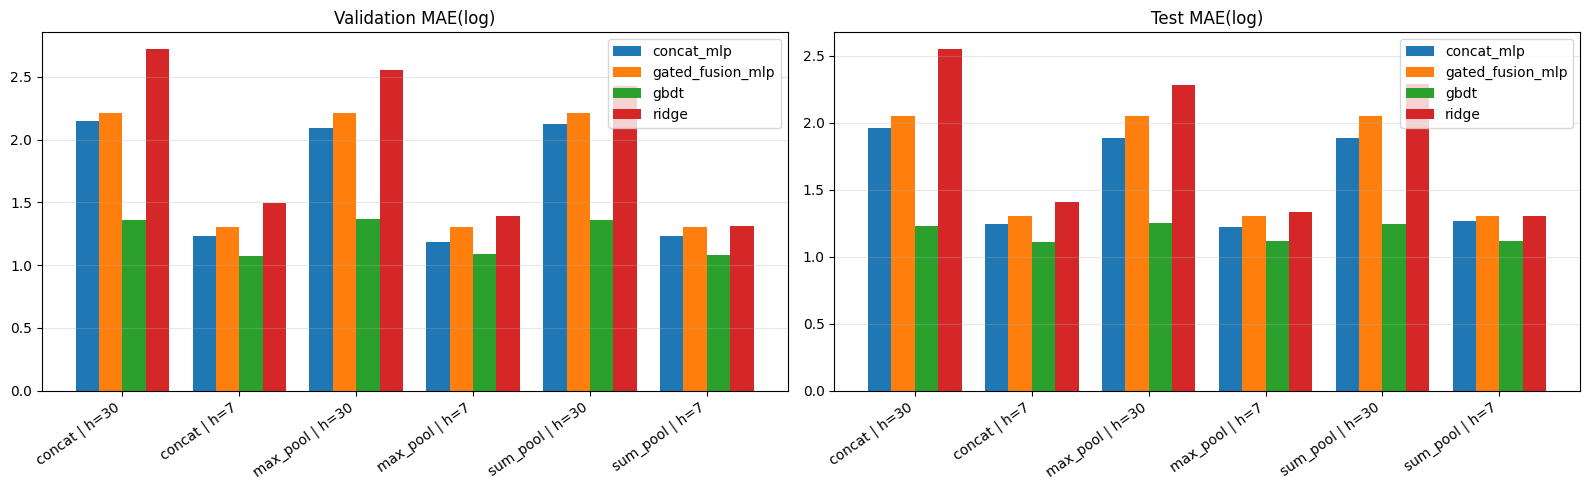

In [10]:
# Barplot comparison across all selected configurations (matplotlib)
plot_df = selected_metrics.copy()
plot_df["label"] = plot_df["strategy"] + " | h=" + plot_df["horizon"].astype(str)
labels = sorted(plot_df["label"].unique())
families = sorted(plot_df["model_family"].unique())
x = np.arange(len(labels))
w = 0.8 / max(len(families), 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)
for idx, fam in enumerate(families):
    sub = plot_df[plot_df["model_family"] == fam].set_index("label")
    y_val = [sub["val_mae_log"].get(lbl, np.nan) for lbl in labels]
    y_test = [sub["test_mae_log"].get(lbl, np.nan) for lbl in labels]
    axes[0].bar(x + idx * w - 0.4 + w / 2, y_val, width=w, label=fam)
    axes[1].bar(x + idx * w - 0.4 + w / 2, y_test, width=w, label=fam)

for ax, ttl in zip(axes, ["Validation MAE(log)", "Test MAE(log)"]):
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=35, ha="right")
    ax.set_title(ttl)
    ax.legend(loc="best")
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


### Winner Table by Strategy/Horizon

This table selects the best family for each `(strategy, horizon)` pair by minimum `test_mae_log`.

What this represents:
- A per-setting leaderboard snapshot.
- Includes corresponding validation MAE for context.

How to interpret:
- If the same family dominates all rows, that family is likely the production candidate.
- Compare winner `test_mae_log` against runner-up externally for practical margin size.



In [11]:
# Best model family per strategy/horizon by test MAE(log)
winners = (
    selected_metrics.sort_values("test_mae_log")
    .groupby(["strategy", "horizon"], as_index=False)
    .first()[["strategy", "horizon", "model_family", "run_id", "test_mae_log", "val_mae_log"]]
    .sort_values(["horizon", "strategy"])
)
display(winners)


,strategy,horizon,model_family,run_id,test_mae_log,val_mae_log
0,concat,7,gbdt,colab-gbdt-20260306T070623Z,1.112712,1.072131
2,max_pool,7,gbdt,colab-gbdt-20260306T070623Z,1.117369,1.090431
4,sum_pool,7,gbdt,colab-gbdt-20260306T070623Z,1.117292,1.083860
1,concat,30,gbdt,colab-gbdt-20260306T070623Z,1.226376,1.361050
3,max_pool,30,gbdt,colab-gbdt-20260306T070623Z,1.249279,1.363901
5,sum_pool,30,gbdt,colab-gbdt-20260306T070623Z,1.246708,1.362891


### Prediction-Level Diagnostics Build

This cell reads every selected `predictions/test.parquet` and derives diagnostic datasets.

What this represents:
- `pred_diag_df`: per-configuration diagnostic summary (MAE/RMSE recalculated from raw predictions, bias, correlation, p95 error).
- `residual_df`: row-level residuals used for distribution and decile plots.
- `segment_df`: text-present slice metrics.

How to interpret:
- `mae_log_recalc` should closely match `test_mae_log` from snapshot metrics.
- Lower `p95_abs_residual_log` indicates better tail behavior.
- Higher `corr_true_pred_log` indicates stronger monotonic fit to targets.



In [12]:
# Load prediction-level test artifacts for selected runs
pred_paths = [
    p for p in SNAPSHOT_ROOT.rglob("predictions/test.parquet") if path_token(p, "run_id") in selected_run_ids
]

diag_rows: list[dict[str, object]] = []
residual_long: list[pd.DataFrame] = []
segment_rows: list[dict[str, object]] = []

for path in sorted(pred_paths):
    run_id = path_token(path, "run_id")
    model_family = path_token(path, "model")
    strategy = path_token(path, "strategy")
    horizon = int(path_token(path, "horizon"))

    frame = pd.read_parquet(path)
    pred_log_col = next((c for c in frame.columns if c.startswith("pred_") and c.endswith("_log")), None)
    pred_raw_col = next((c for c in frame.columns if c.startswith("pred_") and c.endswith("_raw")), None)
    if pred_log_col is None or "y_true_log" not in frame.columns:
        continue

    y_true_log = frame["y_true_log"].astype(float)
    y_pred_log = frame[pred_log_col].astype(float)
    residual_log = y_pred_log - y_true_log
    abs_residual_log = residual_log.abs()

    corr = float(np.corrcoef(y_true_log, y_pred_log)[0, 1]) if len(frame) > 1 else np.nan
    diag = {
        "run_id": run_id,
        "model_family": model_family,
        "strategy": strategy,
        "horizon": horizon,
        "n": int(len(frame)),
        "pred_log_col": pred_log_col,
        "pred_raw_col": pred_raw_col,
        "mae_log_recalc": float(abs_residual_log.mean()),
        "rmse_log_recalc": float(np.sqrt(np.mean(residual_log ** 2))),
        "bias_log": float(residual_log.mean()),
        "corr_true_pred_log": corr,
        "p95_abs_residual_log": float(np.quantile(abs_residual_log, 0.95)),
        "path": str(path),
    }

    if pred_raw_col is not None and "y_true_raw" in frame.columns:
        y_true_raw = frame["y_true_raw"].astype(float)
        y_pred_raw = frame[pred_raw_col].astype(float)
        residual_raw = y_pred_raw - y_true_raw
        diag["mae_raw_recalc"] = float(np.mean(np.abs(residual_raw)))
        diag["rmse_raw_recalc"] = float(np.sqrt(np.mean(residual_raw ** 2)))
        denom = y_true_raw.replace(0, np.nan)
        ape = (np.abs(residual_raw) / denom).replace([np.inf, -np.inf], np.nan).dropna()
        diag["mape_raw"] = float(ape.mean()) if len(ape) else np.nan
    diag_rows.append(diag)

    long = pd.DataFrame(
        {
            "run_id": run_id,
            "model_family": model_family,
            "strategy": strategy,
            "horizon": horizon,
            "video_id": frame.get("video_id", pd.Series([None] * len(frame))),
            "text_present": frame.get("text_present", pd.Series([np.nan] * len(frame))),
            "y_true_log": y_true_log.values,
            "pred_log": y_pred_log.values,
            "residual_log": residual_log.values,
            "abs_residual_log": abs_residual_log.values,
        }
    )
    residual_long.append(long)

    if "text_present" in frame.columns:
        seg = pd.DataFrame({
            "text_present": frame["text_present"],
            "abs_residual_log": abs_residual_log,
        }).dropna()
        if not seg.empty:
            for key, sub in seg.groupby("text_present"):
                segment_rows.append({
                    "run_id": run_id,
                    "model_family": model_family,
                    "strategy": strategy,
                    "horizon": horizon,
                    "text_present": key,
                    "n": int(len(sub)),
                    "mae_log": float(sub["abs_residual_log"].mean()),
                })

pred_diag_df = pd.DataFrame(diag_rows).sort_values("mae_log_recalc").reset_index(drop=True)
residual_df = pd.concat(residual_long, ignore_index=True) if residual_long else pd.DataFrame()
segment_df = pd.DataFrame(segment_rows)

print(f"prediction test files used: {len(pred_paths)}")
print(f"diagnostic rows: {len(pred_diag_df)}")
display(pred_diag_df.head(24))


prediction test files used: 24
diagnostic rows: 24


,run_id,model_family,strategy,horizon,n,pred_log_col,pred_raw_col,mae_log_recalc,rmse_log_recalc,bias_log,corr_true_pred_log,p95_abs_residual_log,path,mae_raw_recalc,rmse_raw_recalc,mape_raw
0,colab-gbdt-20260306T070623Z,gbdt,concat,7,808,pred_gbdt_log,pred_gbdt_raw,1.112712,1.369527,0.013400,0.643301,2.689562,../analysis/s3_snapshots/models/snapshots/run_...,8.093513e+05,2.643980e+06,2.097589
1,colab-gbdt-20260306T070623Z,gbdt,sum_pool,7,808,pred_gbdt_log,pred_gbdt_raw,1.117292,1.373557,0.010191,0.639973,2.661708,../analysis/s3_snapshots/models/snapshots/run_...,8.055506e+05,2.617620e+06,2.080569
2,colab-gbdt-20260306T070623Z,gbdt,max_pool,7,808,pred_gbdt_log,pred_gbdt_raw,1.117369,1.368525,0.013934,0.644061,2.598005,../analysis/s3_snapshots/models/snapshots/run_...,8.010773e+05,2.597330e+06,2.074876
3,colab-concat_mlp-20260306T054620Z,concat_mlp,max_pool,7,808,pred_concat_mlp_log,pred_concat_mlp_raw,1.224115,1.533484,-0.030523,0.516860,2.960319,../analysis/s3_snapshots/models/snapshots/run_...,8.262075e+05,2.665616e+06,2.939554
4,colab-gbdt-20260306T070623Z,gbdt,concat,30,733,pred_gbdt_log,pred_gbdt_raw,1.226376,1.621242,-0.133338,0.848091,3.268727,../analysis/s3_snapshots/models/snapshots/run_...,1.836433e+06,6.604735e+06,37.800221
5,colab-concat_mlp-20260306T054620Z,concat_mlp,concat,7,808,pred_concat_mlp_log,pred_concat_mlp_raw,1.241039,1.549624,-0.053497,0.506439,3.047273,../analysis/s3_snapshots/models/snapshots/run_...,8.270209e+05,2.596384e+06,3.245948
6,colab-gbdt-20260306T070623Z,gbdt,sum_pool,30,733,pred_gbdt_log,pred_gbdt_raw,1.246708,1.638413,-0.133030,0.844648,3.199114,../analysis/s3_snapshots/models/snapshots/run_...,1.839439e+06,6.604782e+06,29.207345
7,colab-gbdt-20260306T070623Z,gbdt,max_pool,30,733,pred_gbdt_log,pred_gbdt_raw,1.249279,1.641917,-0.145022,0.844069,3.242141,../analysis/s3_snapshots/models/snapshots/run_...,1.862491e+06,6.657582e+06,36.186700
8,colab-concat_mlp-20260306T054620Z,concat_mlp,sum_pool,7,808,pred_concat_mlp_log,pred_concat_mlp_raw,1.264093,1.592141,0.238098,0.488481,3.091055,../analysis/s3_snapshots/models/snapshots/run_...,8.588471e+05,2.568460e+06,4.224610
9,colab-ridge-20260306T070324Z,ridge,sum_pool,7,808,pred_ridge_log,pred_ridge_raw,1.302043,1.620047,0.014075,0.449283,3.151886,../analysis/s3_snapshots/models/snapshots/run_...,8.838246e+05,2.749557e+06,3.351675


### Boxplot: Absolute Residual Distribution by Family

This plot compares residual spread across model families using all selected prediction rows.

What this represents:
- Each box shows distribution of `abs_residual_log` for one family.
- Median and spread summarize central and tail error tendencies.

How to interpret:
- Lower median and tighter spread are better.
- Wide boxes indicate unstable performance across samples.
- This is a practical robustness view beyond average MAE alone.



/var/folders/dw/kgzc63q13yx4h7yfxw9hn9j80000gn/T/ipykernel_90857/3358864813.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=family_order, showfliers=False)


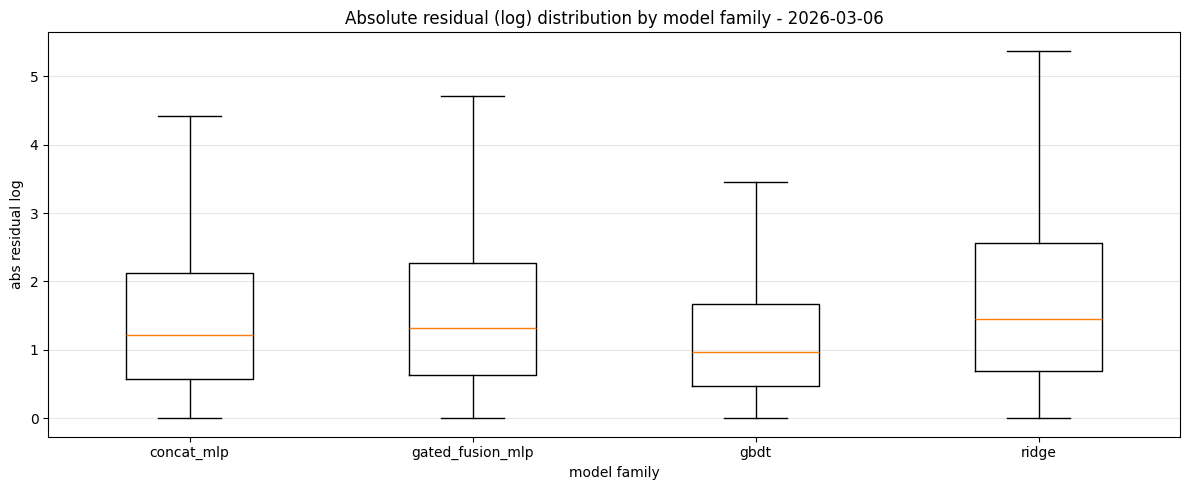

In [13]:
# Residual profile by model family
if residual_df.empty:
    print("No residual rows available.")
else:
    fig, ax = plt.subplots(figsize=(12, 5))
    family_order = sorted(residual_df["model_family"].unique())
    data = [residual_df.loc[residual_df["model_family"] == f, "abs_residual_log"].values for f in family_order]
    ax.boxplot(data, labels=family_order, showfliers=False)
    ax.set_title(f"Absolute residual (log) distribution by model family - {TARGET_DATE}")
    ax.set_xlabel("model family")
    ax.set_ylabel("abs residual log")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


### Decile Analysis: Error vs Target Magnitude

This section bins rows by `y_true_log` decile and computes mean absolute residual in each bin.

What this represents:
- How model error changes from low-view to high-view target regimes.
- The table gives exact values; the line plot shows shape/trend.

How to interpret:
- Rising curves at high deciles indicate difficulty on high-virality cases.
- Flat curves indicate more uniform error across target scale.
- Cross-family separation per decile shows where each model is strongest/weakest.



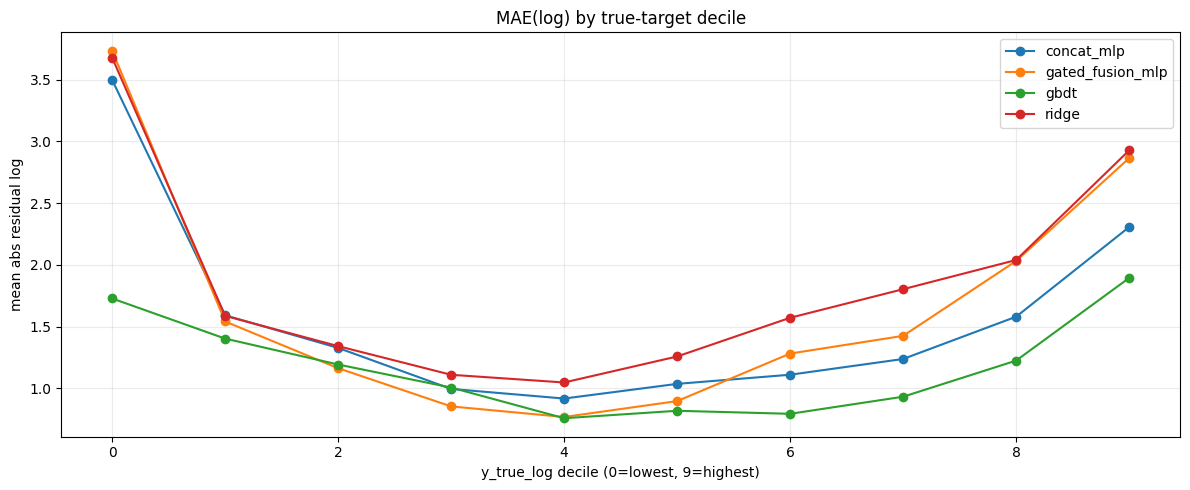

,model_family,y_decile,mae_log,n
0,concat_mlp,0,3.497612,465
1,concat_mlp,1,1.591396,462
2,concat_mlp,2,1.327134,462
3,concat_mlp,3,0.994986,462
4,concat_mlp,4,0.917176,462
5,concat_mlp,5,1.035971,462
6,concat_mlp,6,1.110081,462
7,concat_mlp,7,1.237502,462
8,concat_mlp,8,1.579886,462
9,concat_mlp,9,2.305686,462


In [14]:
# Error by true-value decile
if residual_df.empty:
    print("No residual rows available.")
else:
    tmp = residual_df.copy()
    tmp["y_decile"] = pd.qcut(tmp["y_true_log"], q=10, labels=False, duplicates="drop")
    dec = (
        tmp.groupby(["model_family", "y_decile"], as_index=False)
        .agg(mae_log=("abs_residual_log", "mean"), n=("abs_residual_log", "size"))
    )
    fig, ax = plt.subplots(figsize=(12, 5))
    for fam in sorted(dec["model_family"].unique()):
        sub = dec[dec["model_family"] == fam]
        ax.plot(sub["y_decile"], sub["mae_log"], marker="o", label=fam)
    ax.set_title("MAE(log) by true-target decile")
    ax.set_xlabel("y_true_log decile (0=lowest, 9=highest)")
    ax.set_ylabel("mean abs residual log")
    ax.legend(loc="best")
    ax.grid(axis="both", alpha=0.25)
    plt.tight_layout()
    plt.show()
    display(dec.head(20))


### Slice Analysis: `text_present`

This section compares mean MAE(log) for rows with and without text content.

What this represents:
- Slice-level robustness and potential modality dependence.
- Aggregated counts are shown to expose slice imbalance.

How to interpret:
- Higher MAE on `text_present=0` indicates model struggles when text is missing.
- Smaller gap between slices indicates better robustness.
- Consider sample imbalance when interpreting confidence of slice differences.



,model_family,text_present,mae_log,n
0,concat_mlp,0.0,1.992864,273
1,concat_mlp,1.0,1.552062,4350
2,gated_fusion_mlp,0.0,2.125314,273
3,gated_fusion_mlp,1.0,1.647637,4350
4,gbdt,0.0,1.195174,273
5,gbdt,1.0,1.177520,4350
6,ridge,0.0,2.090887,273
7,ridge,1.0,1.848356,4350


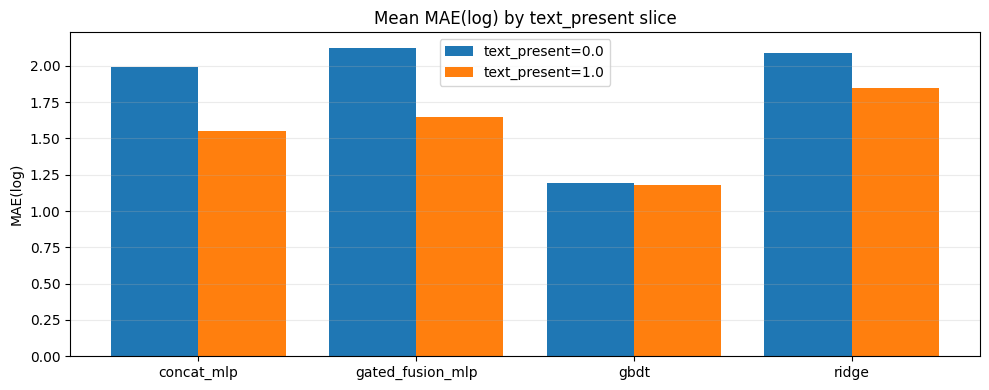

In [15]:
# Slice comparison: text present vs absent
if segment_df.empty:
    print("No text_present slices available in predictions.")
else:
    agg_seg = (
        segment_df.groupby(["model_family", "text_present"], as_index=False)
        .agg(mae_log=("mae_log", "mean"), n=("n", "sum"))
    )
    display(agg_seg.sort_values(["model_family", "text_present"]))
    families = sorted(agg_seg["model_family"].unique())
    slices = sorted(agg_seg["text_present"].unique())
    x = np.arange(len(families))
    w = 0.8 / max(len(slices), 1)
    fig, ax = plt.subplots(figsize=(10, 4))
    for idx, sl in enumerate(slices):
        sub = agg_seg[agg_seg["text_present"] == sl].set_index("model_family")
        vals = [sub["mae_log"].get(f, np.nan) for f in families]
        ax.bar(x + idx * w - 0.4 + w / 2, vals, width=w, label=f"text_present={sl}")
    ax.set_xticks(x)
    ax.set_xticklabels(families)
    ax.set_title("Mean MAE(log) by text_present slice")
    ax.set_ylabel("MAE(log)")
    ax.legend(loc="best")
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()


### Deep Dive: Best Configuration

This section visualizes the best config from `pred_diag_df` and inspects its hardest examples.

What this represents:
- Scatter 1: predicted vs true (ideal points lie near diagonal).
- Histogram: residual distribution and bias around zero.
- Scatter 2: residual magnitude vs target magnitude (heteroscedasticity check).
- Outlier table: top-25 largest absolute residual rows.

How to interpret:
- Tight diagonal alignment implies better calibration in log space.
- Residual center near 0 indicates low bias.
- Strong residual growth with target suggests high-end difficulty.
- Outliers should be reviewed for data quality or edge-case behavior.



Best config:


,run_id,model_family,strategy,horizon,n,pred_log_col,pred_raw_col,mae_log_recalc,rmse_log_recalc,bias_log,corr_true_pred_log,p95_abs_residual_log,path,mae_raw_recalc,rmse_raw_recalc,mape_raw
0,colab-gbdt-20260306T070623Z,gbdt,concat,7,808,pred_gbdt_log,pred_gbdt_raw,1.112712,1.369527,0.0134,0.643301,2.689562,../analysis/s3_snapshots/models/snapshots/run_...,809351.263222,2643979.517485,2.097589


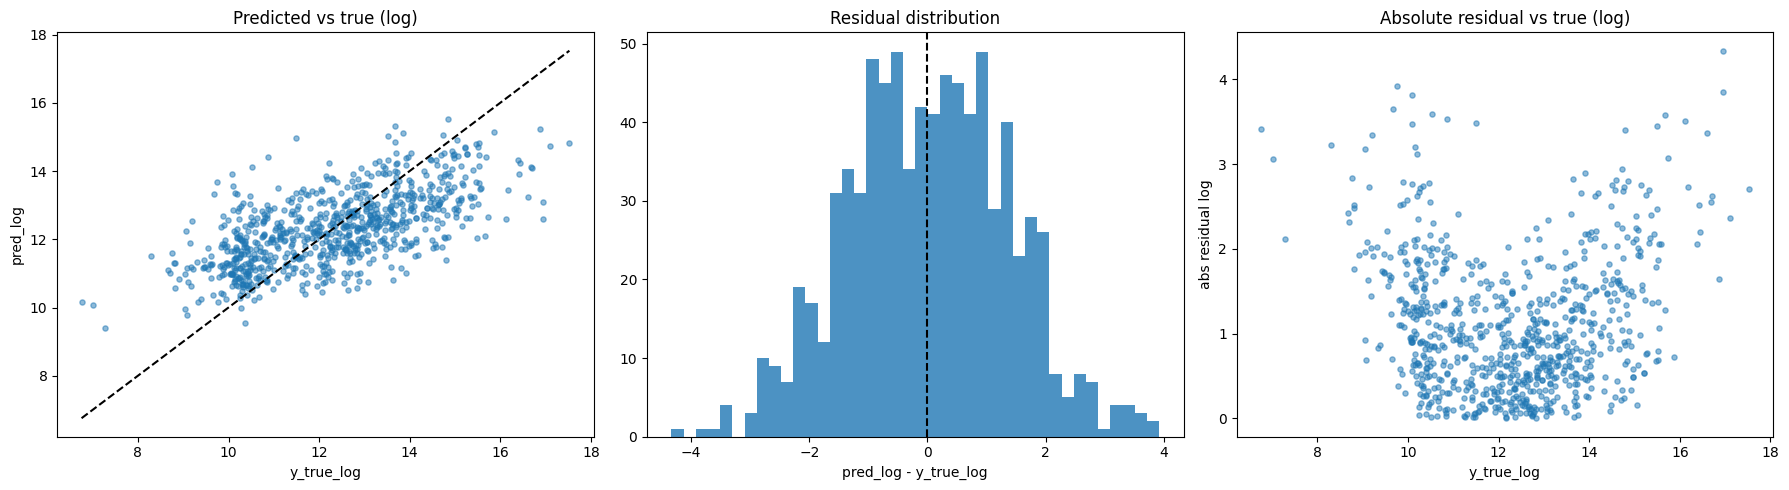

,video_id,y_true_log,pred_log,residual_log,abs_residual_log
90,6b3NEAyp-Ig,16.942041,12.605384,-4.336658,4.336658
240,WsA2oG9eDRQ,9.755683,13.679472,3.923789,3.923789
412,qMPzZF-KS00,16.953300,13.099460,-3.853841,3.853841
65,RtwyKAfgGWg,10.078113,13.897998,3.819885,3.819885
263,haj786AzMl0,9.676963,13.331491,3.654528,3.654528
248,AnhsQCKIXzw,10.520914,14.106319,3.585405,3.585405
424,ieRz41ufzVI,15.661158,12.082686,-3.578471,3.578471
33,YzZOHEKIbSM,10.869311,14.403090,3.533778,3.533778
315,fe3t7uLUFyI,16.115679,12.605498,-3.510180,3.510180
296,OZzbkDhtRvU,11.489565,14.977568,3.488003,3.488003


In [16]:
# Deep dive into best configuration by test MAE(log)
if pred_diag_df.empty:
    print("No prediction diagnostics available.")
else:
    best = pred_diag_df.iloc[0]
    best_path = Path(best["path"])
    frame = pd.read_parquet(best_path)
    pred_log_col = best["pred_log_col"]
    y_true_log = frame["y_true_log"].astype(float).to_numpy()
    y_pred_log = frame[pred_log_col].astype(float).to_numpy()
    residual_log = y_pred_log - y_true_log

    print("Best config:")
    display(best.to_frame().T)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    lo = float(min(y_true_log.min(), y_pred_log.min()))
    hi = float(max(y_true_log.max(), y_pred_log.max()))

    axes[0].scatter(y_true_log, y_pred_log, s=14, alpha=0.5)
    axes[0].plot([lo, hi], [lo, hi], linestyle="--", color="black")
    axes[0].set_title("Predicted vs true (log)")
    axes[0].set_xlabel("y_true_log")
    axes[0].set_ylabel("pred_log")

    axes[1].hist(residual_log, bins=40, alpha=0.8)
    axes[1].axvline(0.0, linestyle="--", color="black")
    axes[1].set_title("Residual distribution")
    axes[1].set_xlabel("pred_log - y_true_log")

    axes[2].scatter(y_true_log, np.abs(residual_log), s=14, alpha=0.5)
    axes[2].set_title("Absolute residual vs true (log)")
    axes[2].set_xlabel("y_true_log")
    axes[2].set_ylabel("abs residual log")

    plt.tight_layout()
    plt.show()

    outliers = (
        pd.DataFrame({
            "video_id": frame.get("video_id", pd.Series([None] * len(frame))),
            "y_true_log": y_true_log,
            "pred_log": y_pred_log,
            "residual_log": residual_log,
            "abs_residual_log": np.abs(residual_log),
        })
        .sort_values("abs_residual_log", ascending=False)
        .head(25)
    )
    display(outliers)


### Report Artifact Export

This final cell writes flattened CSV outputs for downstream reporting and reproducibility.

What this represents:
- `metrics_selected_*.csv`: configuration-level metrics used in comparisons.
- `prediction_diag_selected_*.csv`: configuration-level diagnostic stats.
- `residual_long_selected_*.csv`: row-level residual dataset.
- `text_slice_selected_*.csv`: slice-level text presence diagnostics.
- `run_selection_*.csv`: exact run set used for this report.

How to interpret:
- These files are the source of truth for any external written summary or dashboard.
- Keep them versioned with date and run IDs to maintain auditability.



In [17]:
# Export flat reports for downstream sharing
report_dir = Path("analysis/s3_snapshots/reports")
report_dir.mkdir(parents=True, exist_ok=True)

selected_metrics_out = report_dir / f"metrics_selected_{TARGET_DATE}.csv"
pred_diag_out = report_dir / f"prediction_diag_selected_{TARGET_DATE}.csv"
selection_out = report_dir / f"run_selection_{TARGET_DATE}.csv"
residual_out = report_dir / f"residual_long_selected_{TARGET_DATE}.csv"
segment_out = report_dir / f"text_slice_selected_{TARGET_DATE}.csv"

selected_metrics.to_csv(selected_metrics_out, index=False)
pred_diag_df.to_csv(pred_diag_out, index=False)
selection_df.to_csv(selection_out, index=False)
if not residual_df.empty:
    residual_df.to_csv(residual_out, index=False)
if not segment_df.empty:
    segment_df.to_csv(segment_out, index=False)

print(f"wrote {selected_metrics_out}")
print(f"wrote {pred_diag_out}")
print(f"wrote {selection_out}")
if residual_out.exists():
    print(f"wrote {residual_out}")
if segment_out.exists():
    print(f"wrote {segment_out}")


wrote analysis/s3_snapshots/reports/metrics_selected_2026-03-06.csv
wrote analysis/s3_snapshots/reports/prediction_diag_selected_2026-03-06.csv
wrote analysis/s3_snapshots/reports/run_selection_2026-03-06.csv
wrote analysis/s3_snapshots/reports/residual_long_selected_2026-03-06.csv
wrote analysis/s3_snapshots/reports/text_slice_selected_2026-03-06.csv
